# Initial imports and constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import math
import pickle
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [3]:
### switch to mask out transits
mask_transits = True
bootstrap = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [4]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Definitions

In [5]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [6]:
def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
       
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        # err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # Find the intersection using root_scalar
        intersections = []
        for k in range(len(tc1) - 1):
            if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
                sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
                if sol.converged:
                    intersections.append((sol.root - min_chi_time))
        errors.append(intersections)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv, errors

In [7]:
def bootstrap_transit_times(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2, num_bootstrap=100):
    '''
    tc: list of arrays, each array contains a grid of tc values around the guess for each transit
    tc_guess: array of tc guess values, one per transit
    '''
    tc_chi = np.zeros(len(tc))
    ttv = np.zeros(len(tc))
    errors = []

    for j in range(len(tc)):
        tc_grid = tc[j]  # fine grid of tc values around guess for this transit
        tc_samples = []

        for _ in range(num_bootstrap):
            # Bootstrap resample the data within the relevant time window
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > start) & (time < end)

            time_boot = time[mask]
            flux_boot = flux[mask]
            flux_err_boot = flux_err[mask]

            # Resample with replacement
            resample_idx = np.random.choice(len(time_boot), size=len(time_boot), replace=True)
            time_sample = time_boot[resample_idx]
            flux_sample = flux_boot[resample_idx]
            flux_err_sample = flux_err_boot[resample_idx]

            chi_sq = np.zeros(len(tc_grid))

            for i, t0 in enumerate(tc_grid):
                params = batman.TransitParams()
                params.t0 = t0
                params.per = per
                params.rp = rp
                params.b = b
                params.T14 = T14
                params.u = [u1, u2]
                params.limb_dark = "quadratic"

                try:
                    model = batman.TransitModel(params, time_sample)
                    model_flux = model.light_curve(params)
                    chi_sq[i] = np.sum(((flux_sample - model_flux) / flux_err_sample)**2)
                except RuntimeError:
                    chi_sq[i] = np.inf  # If model fails, mark as bad

            best_tc = tc_grid[np.argmin(chi_sq)]
            tc_samples.append(best_tc)

        tc_samples = np.array(tc_samples)
        median_tc = np.median(tc_samples)
        tc_chi[j] = median_tc
        ttv[j] = median_tc - tc_guess[j]
        err_lo = np.percentile(tc_samples, 16) - median_tc
        err_hi = np.percentile(tc_samples, 84) - median_tc
        errors.append((abs(err_lo), abs(err_hi)))

    return tc_chi, ttv, errors


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [9]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Sort by phase
    sort_idx = np.argsort(folded_phase)
    folded_phase = folded_phase[sort_idx]
    folded_flux = folded_flux[sort_idx]

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Get transit guess times

In [10]:
if bootstrap == True:
    # Load the data from the file
    file_path = 'toi_1339_bls_data.pkl'
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
else:
    # Load the data from the file
    file_path = 'toi_1339_bls_data_no_bootstrap.pkl'
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
# print(data)

In [11]:
transit_times_1 = data['transit_times_1']
transit_times_2 = data['transit_times_2']
transit_times_3 = data['transit_times_3']
time = data['time']
flux = data['flux']
flux_err = data['flux_err']
planet_1_period = data['planet_1_period']
planet_2_period = data['planet_2_period']
planet_3_period = data['planet_3_period']
planet_1_t0 = data['planet_1_t0']
planet_2_t0 = data['planet_2_t0']
planet_3_t0 = data['planet_3_t0']
print(planet_1_t0)

1715.3907737341071


# System constants 

In [12]:
### stellar params
q1 = 0.304
q2 = 0.40

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

0.44108956006688715
0.11027239001672175


In [13]:
### Planet params
# planet b
per_1=  8.8803232 #8.8803256
rp_1= 0.0333265970068500 #0.03319
b_1=  0.522936735232103 #0.610
T14_1= 3.06623299086887 * 0.0416667  #2.939 * 0.0416667  # convert to days from hours 


In [14]:
### Planet params
per_2=  28.579889 #28.579743
rp_2= 0.0312382795966642 #0.03118
b_2=  0.482378819760311 #0.630
T14_2= 4.47016349523855 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 


In [15]:
### Planet params 
# planet b
per_3=  38.352562 #38.353037
rp_3=  0.0305954481349672 #0.02916
b_3=  0.323085496752003 #0.440
T14_3= 5.51199861214238 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


# Planet 1

In [16]:
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [17]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
errors = []
err_tc_chi = []

In [18]:
if bootstrap == True:
    tc_chi_1, ttv_1, tc_err1 = bootstrap_transit_times(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

else:
    tc_chi_1, ttv_1, tc_err1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [19]:
print(tc_chi_1)
print(tc_err1)

[1715.3549092  1733.11558647 1741.99617437 1759.75864806 1768.63791554
 1786.39893646 1795.28297492 1804.15958693 1813.04216926 1821.91789761
 1830.80156766 1839.68065239 1875.20165235 1892.96274789 1901.84315893
 1910.72219763 1919.60164891 1964.00349611 1972.88423452 1981.7648828
 1990.64477483 1999.5250232  2008.40545702 2425.78171907 2434.66251826
 2443.54242755 2612.26826469 2621.15109341 2630.02758785 2647.78993505
 2656.66944084 2701.07258937 2709.95149218 2718.83240221 2727.71095544
 2736.59263097 2798.75435848 2807.63571139 2816.51470333 2825.39591176
 2834.27753264 2843.15668893 2852.03782905 2914.19743215 2923.07769861
 2931.9575024  2940.84007071 2949.72029012 2958.60155892 3296.05083554
 3340.45392127 3349.33440094 3358.21289422 3367.09919651 3375.97506048
 3384.85472898 3393.73776854 3402.617152   3420.37703733 3438.13769173
 3447.01865068 3455.8988675  3464.77921478 3473.66223024 3535.8219518
 3544.7006252  3553.58250042 3562.46345707 3571.34463316 3580.22242952
 3615.74

In [20]:
### after inspection of single transits
values_to_remove_1 = [2612.028148, 2709.95157559]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_1 = [x for x in tc_chi_1 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_1)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_1_cleaned = []
ttv_1_cleaned = []
tc_err_1_cleaned = []

for i in range(len(tc_chi_1)):
    if not any(math.isclose(tc_chi_1[i], val, abs_tol=tolerance) for val in values_to_remove_1):
        tc_chi_1_cleaned.append(tc_chi_1[i])
        ttv_1_cleaned.append(ttv_1[i])
        tc_err_1_cleaned.append(tc_err1[i])

# Overwrite the originals if needed
tc_chi_1 = tc_chi_1_cleaned
ttv_1 = ttv_1_cleaned
tc_err1 = tc_err_1_cleaned
print("Modified List (after removal):", tc_chi_1)
# print(tc_err1)


Modified List (after removal): [1715.3549092017722, 1733.115586473646, 1741.9961743737624, 1759.758648059144, 1768.6379155429108, 1786.3989364624229, 1795.2829749153886, 1804.1595869333155, 1813.0421692624163, 1821.9178976126339, 1830.8015676553691, 1839.680652386748, 1875.2016523497389, 1892.9627478939042, 1901.8431589320448, 1910.7221976307305, 1919.601648913385, 1964.003496109569, 1972.884234520876, 1981.7648828028748, 1990.6447748325165, 1999.5250232040162, 2008.4054570200103, 2425.781719069658, 2434.662518257186, 2443.5424275490977, 2621.1510934061903, 2630.027587848815, 2647.7899350458606, 2656.66944084259, 2701.072589367608, 2718.832402209758, 2727.710955442671, 2736.5926309680335, 2798.754358484076, 2807.6357113864506, 2816.51470333335, 2825.395911761419, 2834.277532641948, 2843.1566889250516, 2852.0378290502304, 2914.1974321456664, 2923.0776986079936, 2931.9575024020814, 2940.840070710424, 2949.7202901197343, 2958.6015589186595, 3296.050835541113, 3340.453921268288, 3349.33440

In [21]:
tc_err_1 = []
for i in range(len(tc_err1)):
    if len(tc_err1[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err1[i][0]**2 + tc_err1[i][1]**2)
        tc_err_1.append(sig)
    else:
        print(f"Unexpected format in tc_err1[{i}]: {tc_err1[i]}, {tc_chi_1[i]}")

# print(tc_err_1)

In [22]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi_1

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_16172/3608561284.py:40: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
/opt/homebrew/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


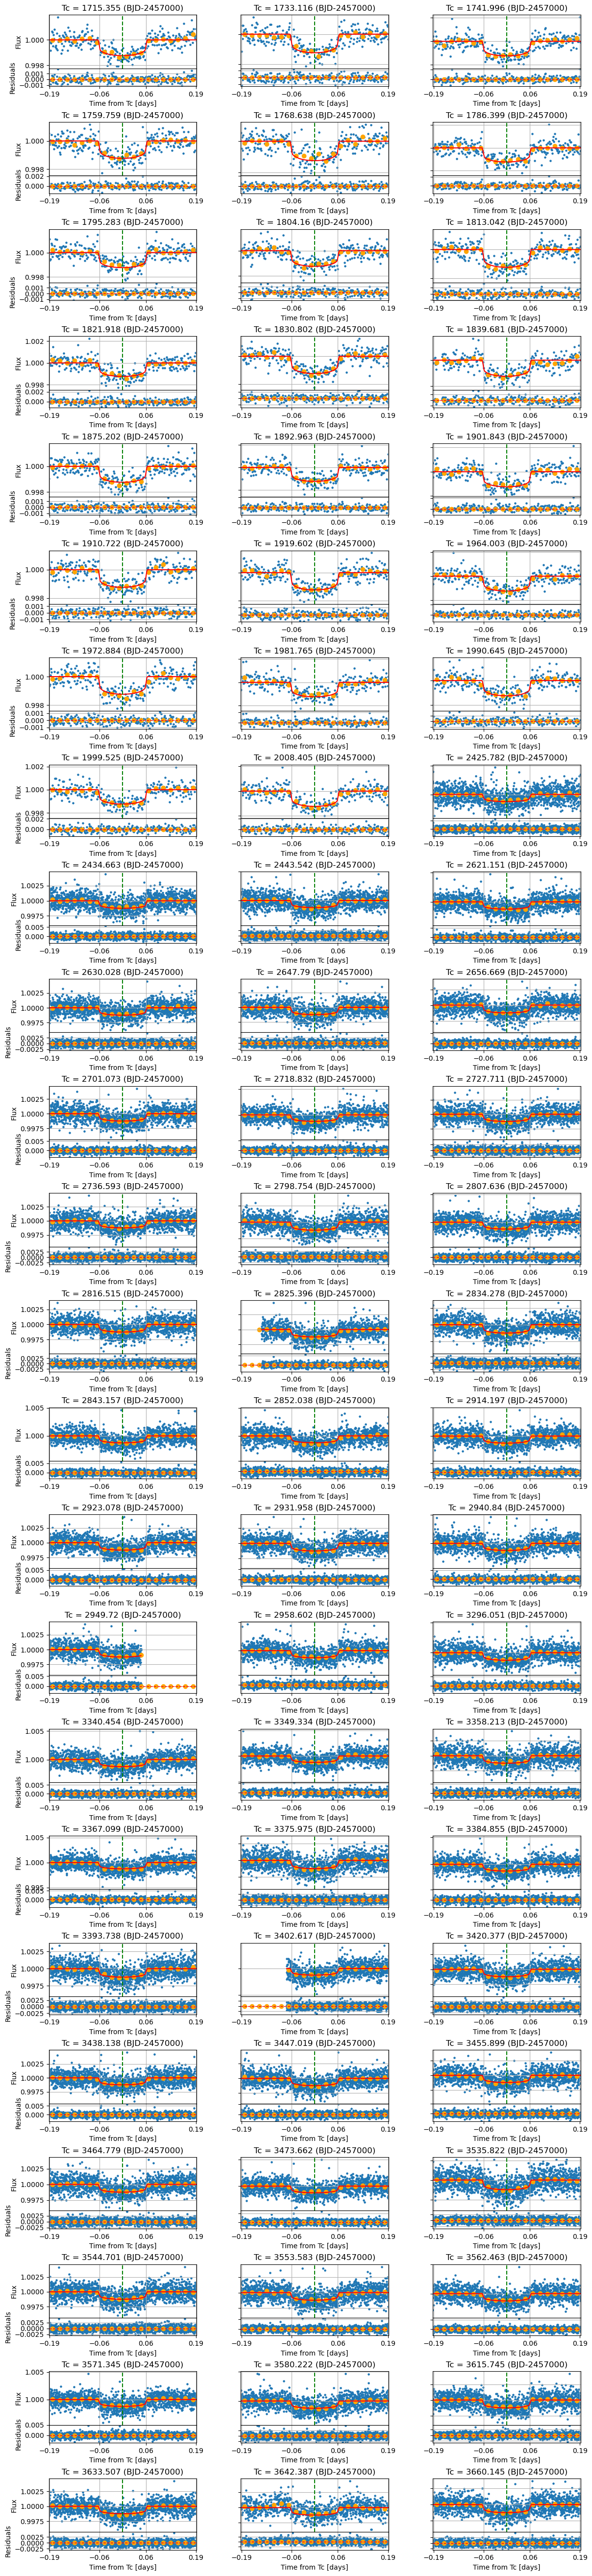

In [23]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

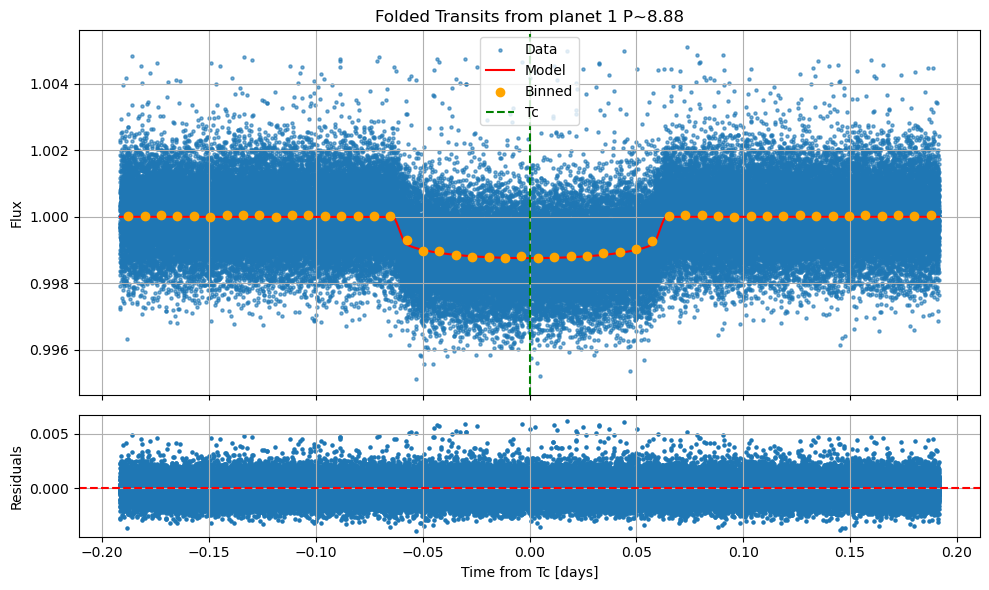

In [24]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 1 P~{round(planet_1_period, 3)}')

# Planet 2

In [25]:
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [26]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
errors = []
err_tc_chi = []

In [27]:
if bootstrap == True:
    tc_chi_2, ttv_2, tc_err2 =  bootstrap_transit_times(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

else:
    tc_chi_2, ttv_2, tc_err2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [28]:
print(tc_chi_2)

[1726.05464104 1754.6342108  1783.21181229 1811.79970925 1840.37532531
 1897.53491287 1926.11611318 2440.54520822 2612.0281482  2640.60652389
 2697.77184061 2726.35289967 2812.09680375 2840.67308347 2926.41942984
 2954.99771396 3297.97103541 3355.12979823 3383.71060541 3440.87662011
 3469.41633888 3555.19563725 3583.77180949 3612.34968722 3640.931355  ]


In [29]:
### after inspection of single transits
values_to_remove_2 = [2612.028148, 2954.99879838, 3469.42643231]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_2 = [x for x in tc_chi_2 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_2)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_2_cleaned = []
ttv_2_cleaned = []
tc_err_2_cleaned = []

for i in range(len(tc_chi_2)):
    if not any(math.isclose(tc_chi_2[i], val, abs_tol=tolerance) for val in values_to_remove_2):
        tc_chi_2_cleaned.append(tc_chi_2[i])
        ttv_2_cleaned.append(ttv_2[i])
        tc_err_2_cleaned.append(tc_err2[i])

# Overwrite the originals if needed
tc_chi_2 = tc_chi_2_cleaned
ttv_2 = ttv_2_cleaned
tc_err2 = tc_err_2_cleaned
print("Modified List (after removal):", tc_chi_2)


Modified List (after removal): [1726.0546410419172, 1754.6342107995306, 1783.2118122855782, 1811.799709252357, 1840.375325305024, 1897.5349128711505, 1926.1161131768363, 2440.545208221896, 2640.6065238883257, 2697.771840611057, 2726.3528996657087, 2812.096803754485, 2840.6730834688888, 2926.4194298413713, 3297.971035411013, 3355.129798226692, 3383.7106054063725, 3440.8766201062163, 3555.1956372484415, 3583.7718094864576, 3612.3496872240244, 3640.931354995604]


In [30]:
tc_err_2 = []
for i in range(len(tc_err2)):
    if len(tc_err2[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err2[i][0]**2 + tc_err2[i][1]**2)
        tc_err_2.append(sig)
    else:
        print(f"Unexpected format in tc_err2[{i}]: {tc_err2[i]}, {tc_chi_2[i]}")

# print(tc_err_2)

In [31]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi_2

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_16172/3608561284.py:40: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]


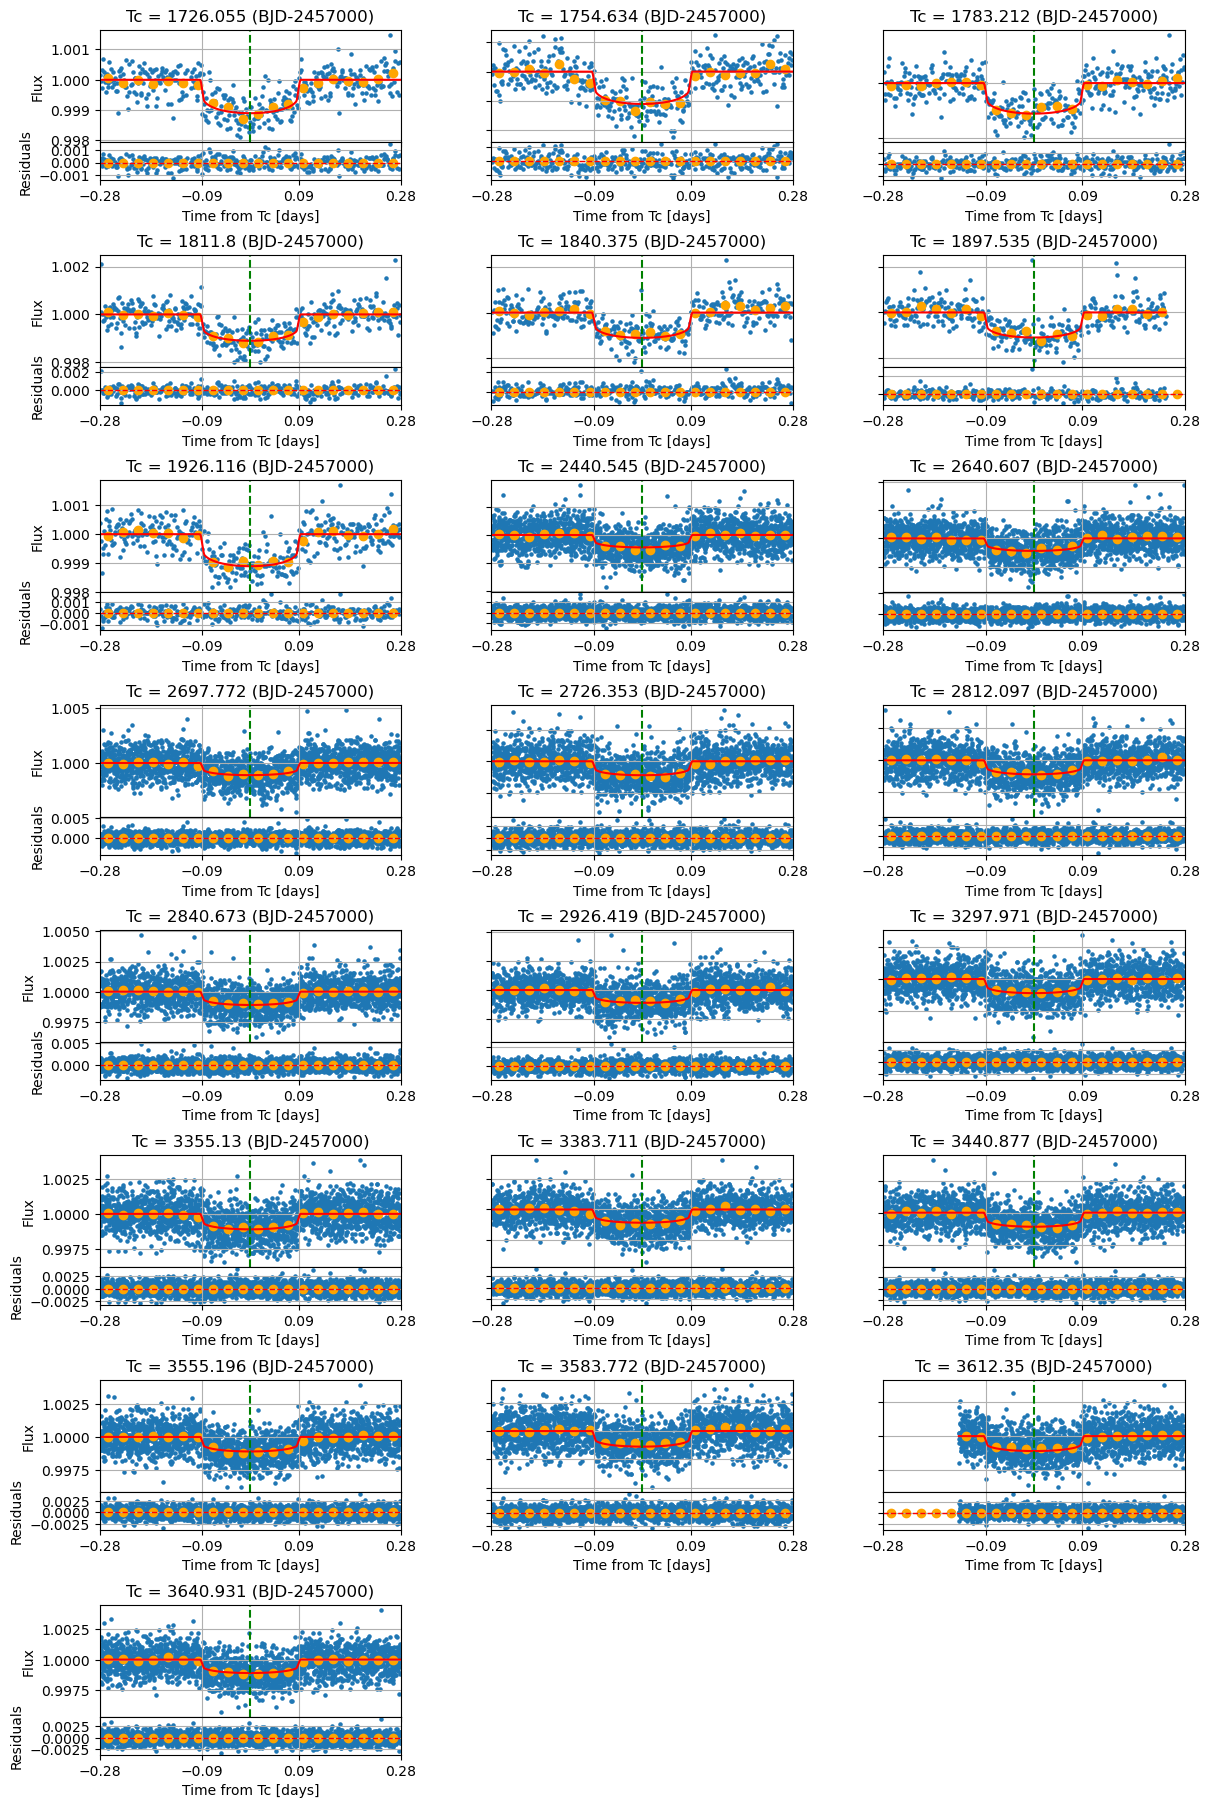

In [32]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

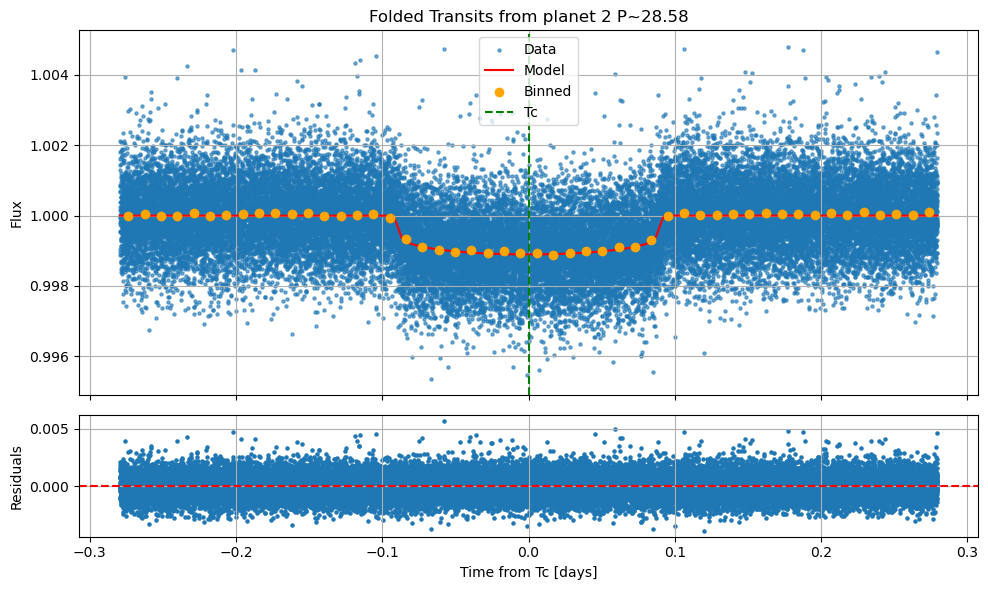

In [33]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 2 P~{round(planet_2_period, 3)}')

# Planet 3

In [34]:
tc_guess_3 = transit_times_3
### get tc ranges for fit
tc_3 = []
for i in range(len(tc_guess_3)):
    start = tc_guess_3[i] - ttv_hour
    end = tc_guess_3[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_3.append(t)

In [35]:
### initialize arrays
tc_chi = np.zeros(len(tc_3))
ttv = np.zeros(len(tc_3))
errors = []
err_tc_chi = []

In [36]:
if bootstrap ==True:
    tc_chi_3, ttv_3, tc_err3 = bootstrap_transit_times(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)

else:
    tc_chi_3, ttv_3, tc_err3 = plot_chi_sq(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)

In [37]:
print(tc_chi_3)

[1743.55216547 1781.90289662 1820.26508912 1896.96211027 1973.66389551
 2433.91685404 2625.67266892 2664.02525977 2702.35263997 2740.71772493
 2817.41068732 2932.46215755 3354.3037884  3392.66102082 3469.36057849
 3546.07312725 3584.39967719 3622.77016853 3661.12722679]


In [38]:
### after inspection of single transits
values_to_remove_3 = [3469.35398856, 3584.39976061]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_3 = [x for x in tc_chi_3 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_3)]

# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_3_cleaned = []
ttv_3_cleaned = []
tc_err_3_cleaned = []

for i in range(len(tc_chi_3)):
    if not any(math.isclose(tc_chi_3[i], val, abs_tol=tolerance) for val in values_to_remove_3):
        tc_chi_3_cleaned.append(tc_chi_3[i])
        ttv_3_cleaned.append(ttv_3[i])
        tc_err_3_cleaned.append(tc_err3[i])

# Overwrite the originals if needed
tc_chi_3 = tc_chi_3_cleaned
ttv_3 = ttv_3_cleaned
tc_err3 = tc_err_3_cleaned


print("Modified List (after removal):", tc_chi_3)


Modified List (after removal): [1743.5521654743457, 1781.9028966159115, 1820.2650891220255, 1896.9621102732976, 1973.6638955051708, 2433.9168540431297, 2625.672668923858, 2664.0252597737876, 2702.352639969187, 2740.7177249328274, 2817.41068731541, 2932.462157552539, 3354.3037884045525, 3392.6610208230263, 3546.073127250395, 3622.7701685262746, 3661.127226788756]


In [39]:
tc_err_3 = []
for i in range(len(tc_err3)):
    if len(tc_err3[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err3[i][0]**2 + tc_err3[i][1]**2)
        tc_err_3.append(sig)
    else:
        print(f"Unexpected format in tc_err3[{i}]: {tc_err3[i]}, {tc_chi_3[i]}")

# print(tc_err_3)

In [40]:
# Transit windows
buffer = 1.5 * T14_3
transit_times_3 = tc_chi_3

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_16172/3608561284.py:40: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]


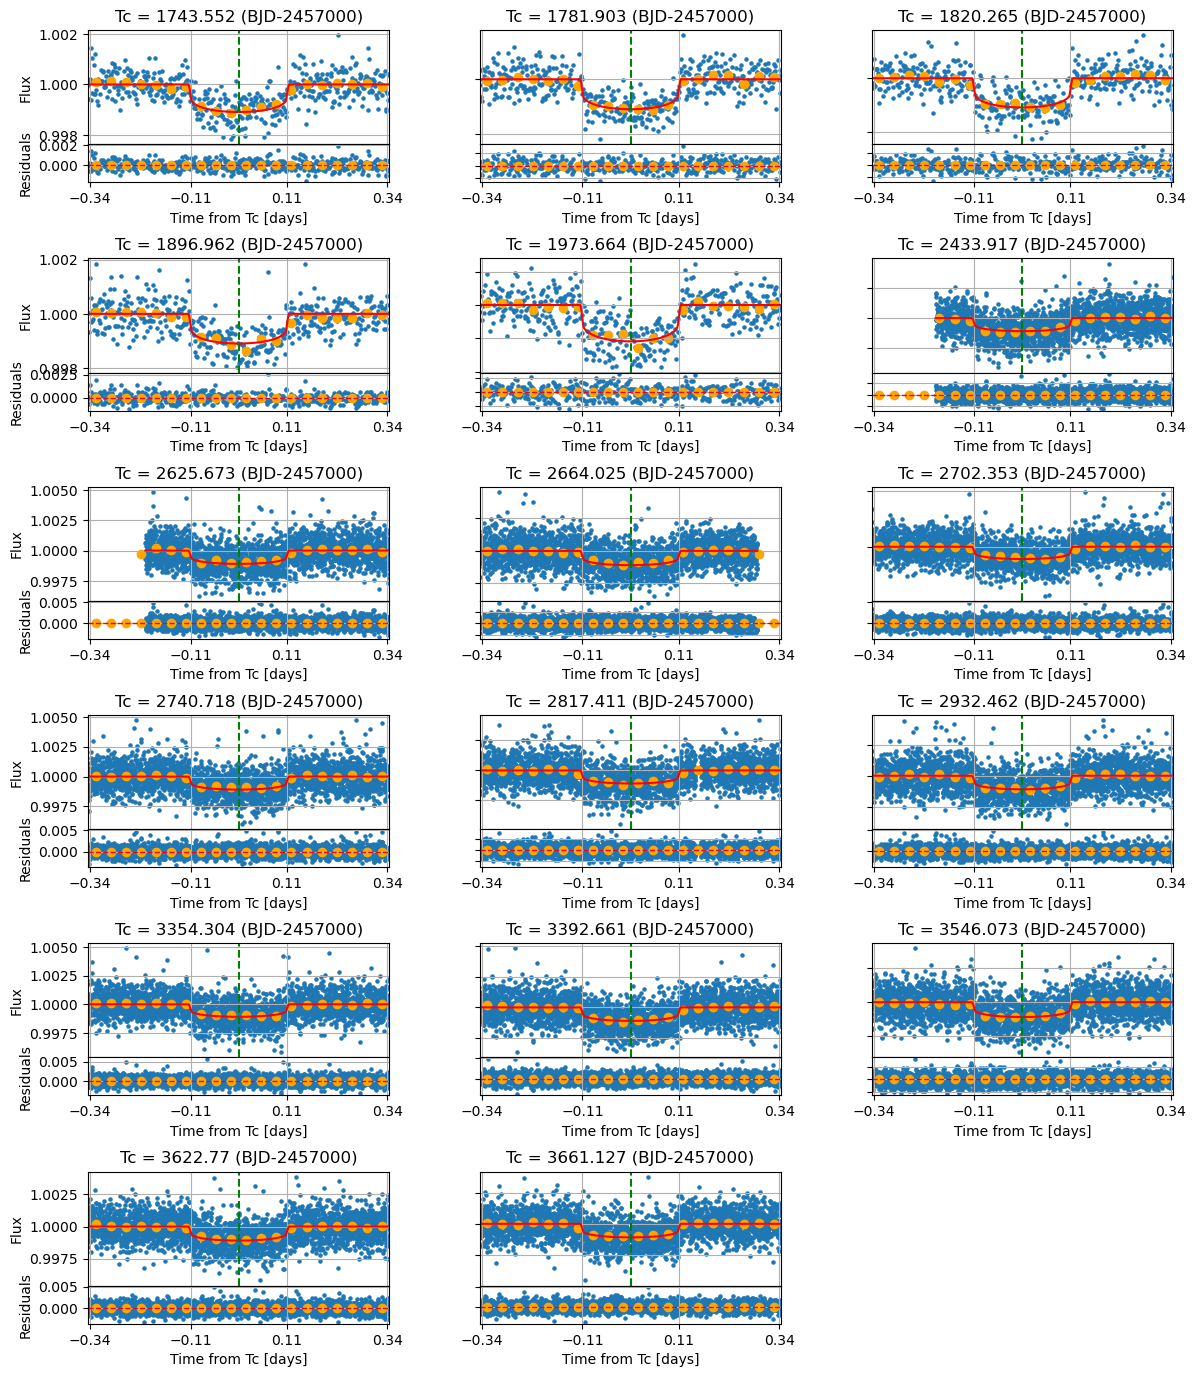

In [41]:
plot_transits(transit_times_3, per_3, rp_3, b_3, T14_3, u1, u2)

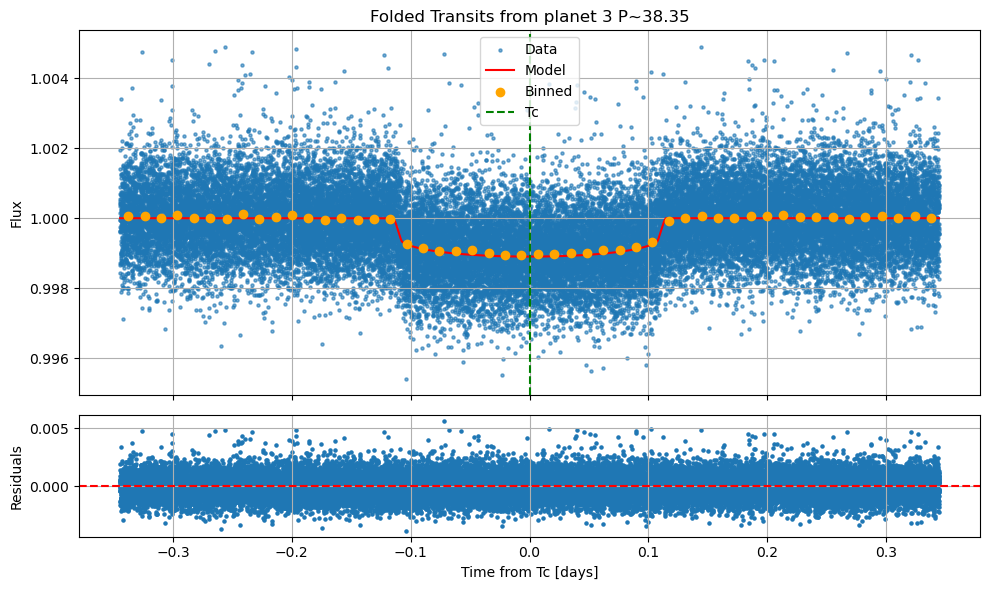

In [42]:
plot_folded_from_transits(transit_times_3, time, flux, per_3, rp_3, b_3, T14_3, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 3 P~{round(planet_3_period, 3)}')

# Save Data

In [43]:
# Calculate the indices of transits for each planet
indices_1 = np.round((transit_times_1 - planet_1_t0) / planet_1_period).astype(int)
indices_2 = np.round((transit_times_2 - planet_2_t0) / planet_2_period).astype(int)
indices_3 = np.round((transit_times_3 - planet_3_t0) / planet_3_period).astype(int)


In [44]:
print(f'Num transits planet 1: {len(transit_times_1)}')
print(f'Num transits planet 2: {len(transit_times_2)}')
print(f'Num transits planet 3: {len(transit_times_3)}')

Num transits planet 1: 72
Num transits planet 2: 22
Num transits planet 3: 17


In [45]:
print(transit_times_2)
print(transit_times_3)
print(tc_err_1)
print(tc_err_2)
print(tc_err_3)
transit_times_2 = np.array(transit_times_2)
transit_times_3 = np.array(transit_times_3)

print("Indices of transits for planet 1:", indices_1)
print("Indices of transits for planet 2:", indices_2)
print("Indices of transits for planet 3:", indices_3)


[1726.0546410419172, 1754.6342107995306, 1783.2118122855782, 1811.799709252357, 1840.375325305024, 1897.5349128711505, 1926.1161131768363, 2440.545208221896, 2640.6065238883257, 2697.771840611057, 2726.3528996657087, 2812.096803754485, 2840.6730834688888, 2926.4194298413713, 3297.971035411013, 3355.129798226692, 3383.7106054063725, 3440.8766201062163, 3555.1956372484415, 3583.7718094864576, 3612.3496872240244, 3640.931354995604]
[1743.5521654743457, 1781.9028966159115, 1820.2650891220255, 1896.9621102732976, 1973.6638955051708, 2433.9168540431297, 2625.672668923858, 2664.0252597737876, 2702.352639969187, 2740.7177249328274, 2817.41068731541, 2932.462157552539, 3354.3037884045525, 3392.6610208230263, 3546.073127250395, 3622.7701685262746, 3661.127226788756]
[0.0012030544410276893, 0.0018465280423239823, 0.001564013484824675, 0.0009437535492665101, 0.0036984785288392925, 0.0014156303242213201, 0.0017968532249568743, 0.0019021960914340514, 0.004273025932543334, 0.0012030544411538134, 0.00

In [46]:
### saving data for planets 2 and 3 (resonant pair)

planet_number = []
for i in range(len(transit_times_1)):
    planet_number.append(1)
for i in range(len(transit_times_2)):
    planet_number.append(2)
for i in range(len(transit_times_3)):
    planet_number.append(3)

all_transit_num = [] 
for i in range(len(indices_1)):
    all_transit_num.append(indices_1[i])
for i in range(len(indices_2)):
    all_transit_num.append(indices_2[i])
for i in range(len(indices_3)):
    all_transit_num.append(indices_3[i])

all_obs_tc = []
for i in range(len(transit_times_1)):
    all_obs_tc.append(transit_times_1[i])
for i in range(len(transit_times_2)):
    all_obs_tc.append(transit_times_2[i])
for i in range(len(transit_times_3)):
    all_obs_tc.append(transit_times_3[i])

all_obs_tc_err = []
for i in range(len(tc_err_1)):
    all_obs_tc_err.append(tc_err_1[i])
for i in range(len(tc_err_2)):
    all_obs_tc_err.append(tc_err_2[i])
for i in range(len(tc_err_3)):
    all_obs_tc_err.append(tc_err_3[i])



In [47]:
if bootstrap == True:
    output_file = "toi_1339_transit_data_all_planets.txt"
else:
    output_file = "toi_1339_transit_data_all_no_bootstrap.txt"
### save
data_to_save = np.column_stack((planet_number, all_transit_num, all_obs_tc, all_obs_tc_err))

### Define header
header = "Planet_num Index Tc Tc_err"

### Save to file
np.savetxt(output_file, data_to_save, fmt='%d %d %.8f %.8f', header=header, comments='')

print(f"Results saved to {output_file}")

Results saved to toi_1339_transit_data_all_planets.txt


In [48]:
### create file for table in paper 
# Map planet numbers to labels (e.g., 1 -> b, 2 -> c, 3 -> d)
planet_labels = {1: "b", 2: "c", 3: "d"}  # adjust if your naming differs

# Output file name
if bootstrap:
    output_file = "toi_1339_transit_data_all_planets_formatted.txt"
else:
    output_file = "toi_1339_transit_data_all_no_bootstrap_formatted.txt"

with open(output_file, "w") as f:
    f.write("% planet, transit index, instrument, time, time_error, notes\n")
    for p, idx, t, terr in zip(planet_number, all_transit_num, all_obs_tc, all_obs_tc_err):
        planet = planet_labels[p]
        instrument = "TESS"
        notes = "A"   # you can change this if needed
        f.write(f"{planet} & {idx} & {instrument} & {t:.4f} & {terr:.4f} & {notes} \\\\\n")

print(f"Formatted results saved to {output_file}")

Formatted results saved to toi_1339_transit_data_all_planets_formatted.txt


In [49]:
print(transit_times_1)
print(transit_times_2)
print(transit_times_3)

[1715.3549092017722, 1733.115586473646, 1741.9961743737624, 1759.758648059144, 1768.6379155429108, 1786.3989364624229, 1795.2829749153886, 1804.1595869333155, 1813.0421692624163, 1821.9178976126339, 1830.8015676553691, 1839.680652386748, 1875.2016523497389, 1892.9627478939042, 1901.8431589320448, 1910.7221976307305, 1919.601648913385, 1964.003496109569, 1972.884234520876, 1981.7648828028748, 1990.6447748325165, 1999.5250232040162, 2008.4054570200103, 2425.781719069658, 2434.662518257186, 2443.5424275490977, 2621.1510934061903, 2630.027587848815, 2647.7899350458606, 2656.66944084259, 2701.072589367608, 2718.832402209758, 2727.710955442671, 2736.5926309680335, 2798.754358484076, 2807.6357113864506, 2816.51470333335, 2825.395911761419, 2834.277532641948, 2843.1566889250516, 2852.0378290502304, 2914.1974321456664, 2923.0776986079936, 2931.9575024020814, 2940.840070710424, 2949.7202901197343, 2958.6015589186595, 3296.050835541113, 3340.453921268288, 3349.3344009433104, 3358.2128942167305, 3

# Check overlapping transits

In [49]:
# Group the sets
transit_sets = [
    ("T1", transit_times_1, T14_1),
    ("T2", transit_times_2, T14_2),
    ("T3", transit_times_3, T14_3),
]

In [50]:
# Function to find overlaps
import itertools
def find_overlapping_transits(sets):
    overlaps = []
    for (label_a, times_a, dur_a), (label_b, times_b, dur_b) in itertools.combinations(sets, 2):
        threshold = 1.5 * max(dur_a, dur_b)
        for idx_a, t1 in enumerate(times_a):
            for idx_b, t2 in enumerate(times_b):
                if abs(t1 - t2) <= threshold:
                    overlaps.append((
                        f"{label_a}[{idx_a}] = ({t1}, T14={dur_a})",
                        f"{label_b}[{idx_b}] = ({t2}, T14={dur_b})"
                    ))
    return overlaps


In [51]:
# Run it
overlaps = find_overlapping_transits(transit_sets)

# Output
if overlaps:
    print(f"Found {len(overlaps)} overlapping transit pairs (within 1.5 × max duration):\n")
    for a, b in overlaps:
        print("Overlap between:")
        print("  ", a)
        print("  ", b)
        print()
else:
    print("No overlapping transits found.")

No overlapping transits found.
